In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
from scipy.stats import pearsonr
from operator import xor
import pygris

In [2]:
data = pd.read_csv("../../data/processed/CA_Fara_500_2019.csv")

In [3]:
los_angeles = data[data["CountyName"] == "Los Angeles"]

In [4]:
los_angeles.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2323 entries, 1 to 5272
Data columns (total 93 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CountyName              2323 non-null   object 
 1   GEOID                   2323 non-null   int64  
 2   TotalPopulation         2323 non-null   int64  
 3   ACCESS2_CrudePrev       2323 non-null   float64
 4   ACCESS2_Crude95CI       2323 non-null   object 
 5   ARTHRITIS_CrudePrev     2323 non-null   float64
 6   ARTHRITIS_Crude95CI     2323 non-null   object 
 7   BINGE_CrudePrev         2323 non-null   float64
 8   BINGE_Crude95CI         2323 non-null   object 
 9   BPHIGH_CrudePrev        2323 non-null   float64
 10  BPHIGH_Crude95CI        2323 non-null   object 
 11  BPMED_CrudePrev         2323 non-null   float64
 12  BPMED_Crude95CI         2323 non-null   object 
 13  CANCER_CrudePrev        2323 non-null   float64
 14  CANCER_Crude95CI        2323 non-null   objec

In [5]:
los_angeles.describe()

,GEOID,TotalPopulation,ACCESS2_CrudePrev,ARTHRITIS_CrudePrev,BINGE_CrudePrev,BPHIGH_CrudePrev,BPMED_CrudePrev,CANCER_CrudePrev,CASTHMA_CrudePrev,CERVICAL_CrudePrev,...,LAPOP1_10,LAPOP05_10,LAPOP1_20,LALOWI1_10,LALOWI05_10,LALOWI1_20,TractLOWI,TotalPop,UninsuredPop,MedHouseInc
count,2.323000e+03,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,...,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2309.000000
mean,6.037403e+09,4225.568231,19.517348,17.252604,17.085019,26.130220,65.742746,5.069694,7.868704,81.094662,...,275.937581,1555.907447,274.564356,61.402927,483.052518,60.936720,1571.591907,4337.666380,155.950495,73221.060199
std,2.231407e+05,1448.867884,9.612127,3.110458,2.346335,4.068094,5.737671,1.519977,1.071323,4.593696,...,898.556866,1693.324758,898.113506,249.631817,662.200037,249.356702,973.734963,1538.590488,98.163804,34507.595867
min,6.037101e+09,59.000000,4.600000,2.500000,8.400000,5.700000,10.900000,0.600000,4.900000,46.100000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9191.000000
25%,6.037211e+09,3228.000000,10.800000,15.200000,15.900000,23.900000,62.600000,3.900000,7.200000,78.600000,...,0.000000,16.500000,0.000000,0.000000,3.500000,0.000000,798.000000,3227.000000,85.000000,48188.000000
50%,6.037405e+09,4113.000000,18.400000,16.800000,17.100000,25.700000,65.700000,4.800000,7.700000,81.300000,...,0.000000,1043.000000,0.000000,0.000000,236.000000,0.000000,1437.000000,4234.000000,140.000000,66174.000000
75%,6.037552e+09,5176.500000,27.200000,19.000000,18.300000,27.900000,69.300000,6.000000,8.500000,84.300000,...,0.000000,2608.000000,0.000000,0.000000,660.000000,0.000000,2189.000000,5326.000000,211.000000,90389.000000
max,6.037980e+09,12544.000000,47.200000,35.200000,29.700000,55.900000,82.100000,12.800000,12.700000,90.100000,...,10889.000000,12544.000000,10889.000000,3206.000000,4234.000000,3206.000000,5514.000000,12463.000000,808.000000,250001.000000


In [6]:
# check for repeat GEO IDS
los_angeles["GEOID"].duplicated().sum()

np.int64(0)

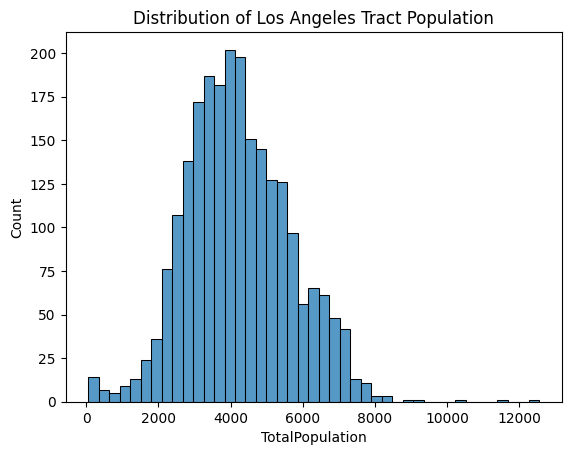

In [7]:
sns.histplot(data=los_angeles["TotalPopulation"])
plt.title("Distribution of Los Angeles Tract Population")
plt.show()

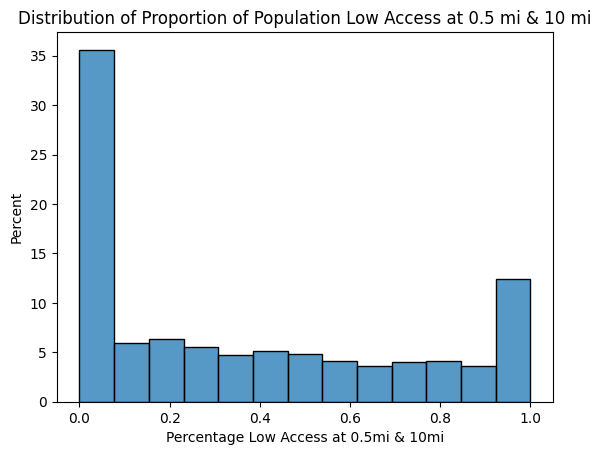

In [8]:
sns.histplot(data=los_angeles["LAPOP05_10"]/los_angeles["TotalPopulation"], stat="percent")
plt.xlabel("Percentage Low Access at 0.5mi & 10mi")
plt.title("Distribution of Proportion of Population Low Access at 0.5 mi & 10 mi")
plt.show()

Correlation Analysis

In [11]:
# Remove unnecessary columns
d_cols = []
for i in los_angeles.columns:
    if re.match(string=i, pattern=r'\S*(CI)$'):
        d_cols.append(i)

d_cols.append("CountyName")
d_cols.append("Geolocation")
d_cols.append("GEOID")

corr_df = los_angeles.drop(columns=d_cols + ["TotalPopulation", "TotalPop"])

# iterate through every correlation pair and append any with p <= 0.05 and correlation >= 0.3
# Opted for pearson r instead of pandas corr f(x) for the associated p value btw
cols: list = corr_df.columns.to_list()
si = {}
while len(cols) != 0:
    ptr = cols[0]
    for i in cols[1:]:
        corr, p = pearsonr(corr_df[ptr], corr_df[i])
        if p <= 0.05 and abs(corr) >= 0.3:
            si[(ptr, i)] = (corr, p)
    cols.pop(0)

In [12]:
# Logic to check if a pair only contains one low access indicator
def pairwise(x, y):
    def low_access(z):
        if "LA" in z :
            return True
        else: 
            return False
    
    la_x = low_access(x)
    la_y = low_access(y)
    
    return xor(la_x, la_y)
    
        
# narrow down data to low access correlations
la_si = {}
la_cols = []
for k, v in si.items():
    if pairwise(k[0], k[1]):
        if k[0] not in la_cols:
            la_cols.append(k[0])
        if k[1] not in la_cols:
            la_cols.append(k[1])
        la_si[k] = v
        print(f'{k[0]} & {k[1]} -- correlation: {v[0]}, p-value: {v[1]}')

ACCESS2_CrudePrev & LILATracts_halfAnd10 -- correlation: 0.3929020750929751, p-value: 1.3042779051020982e-86
CASTHMA_CrudePrev & LILATracts_halfAnd10 -- correlation: 0.37032355030264613, p-value: 2.0339490099531834e-76
CHOLSCREEN_CrudePrev & LILATracts_halfAnd10 -- correlation: -0.3415975291151818, p-value: 1.4095745388371625e-64
COLON_SCREEN_CrudePrev & LILATracts_halfAnd10 -- correlation: -0.3997217410414295, p-value: 7.515045359635223e-90
COPD_CrudePrev & LILATracts_halfAnd10 -- correlation: 0.30067866075518057, p-value: 9.56750208057246e-50
CSMOKING_CrudePrev & LILATracts_halfAnd10 -- correlation: 0.4118566471659303, p-value: 8.329891048360792e-96
DENTAL_CrudePrev & LILATracts_halfAnd10 -- correlation: -0.43308922092735946, p-value: 7.77286938628452e-107
DIABETES_CrudePrev & LILATracts_halfAnd10 -- correlation: 0.3540331074737596, p-value: 1.491100149812476e-69
GHLTH_CrudePrev & LILATracts_halfAnd10 -- correlation: 0.41993892118278475, p-value: 6.534378629974605e-100
KIDNEY_CrudePr

In [13]:
print(la_cols)

['ACCESS2_CrudePrev', 'LILATracts_halfAnd10', 'CASTHMA_CrudePrev', 'CHOLSCREEN_CrudePrev', 'COLON_SCREEN_CrudePrev', 'COPD_CrudePrev', 'CSMOKING_CrudePrev', 'DENTAL_CrudePrev', 'DIABETES_CrudePrev', 'GHLTH_CrudePrev', 'KIDNEY_CrudePrev', 'LPA_CrudePrev', 'MHLTH_CrudePrev', 'OBESITY_CrudePrev', 'PHLTH_CrudePrev', 'SLEEP_CrudePrev', 'Pop2010', 'LAPOP05_10', 'LALOWI05_10', 'LowIncomeTracts', 'PovertyRate', 'TractLOWI', 'LILATracts_Vehicle', 'HUNVFlag', 'LATractsVehicle_20']


In [14]:
la_corr = los_angeles.loc[:, la_cols]

In [15]:
comp_data = data.loc[:, la_cols + ["CountyName"]]
comp_data["Los Angeles"] = comp_data["CountyName"] == "Los Angeles"

In [16]:
def filter_data(data, col):
    cols = []
    if type(col) == list:
        cols = col
        col.append("Los Angeles")
    else:
        cols.append(col)
        cols.append("Los Angeles")
    return data.loc[: , cols]

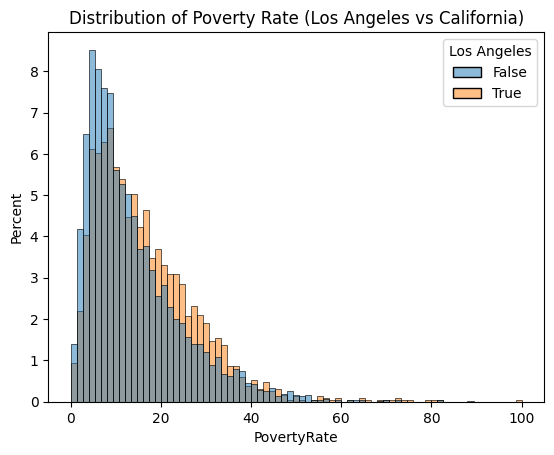

In [17]:
sns.histplot(data=filter_data(comp_data, 'PovertyRate'), x="PovertyRate", hue="Los Angeles", common_norm=False, stat="percent")
plt.title("Distribution of Poverty Rate (Los Angeles vs California)")
plt.show()

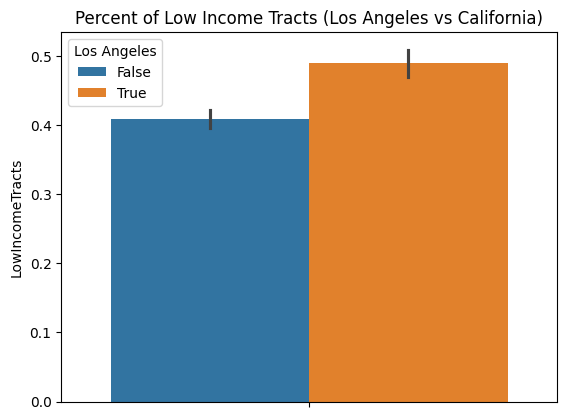

In [18]:
sns.barplot(data=filter_data(comp_data, 'LowIncomeTracts'), y="LowIncomeTracts", hue="Los Angeles")
plt.title("Percent of Low Income Tracts (Los Angeles vs California)")
plt.show()

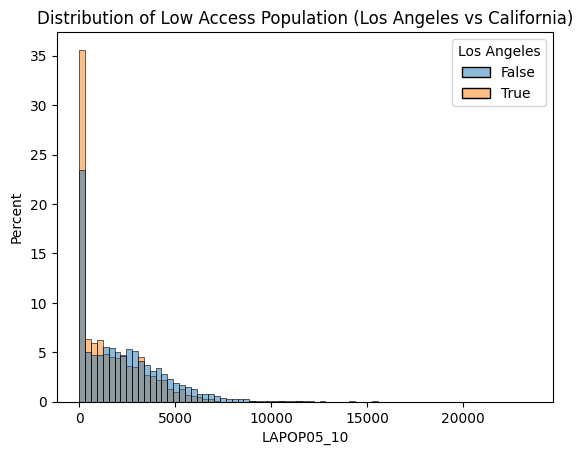

In [19]:
sns.histplot(data=filter_data(comp_data, 'LAPOP05_10'), x='LAPOP05_10', hue='Los Angeles', common_norm=False, stat='percent')
plt.title("Distribution of Low Access Population (Los Angeles vs California)")
plt.show()

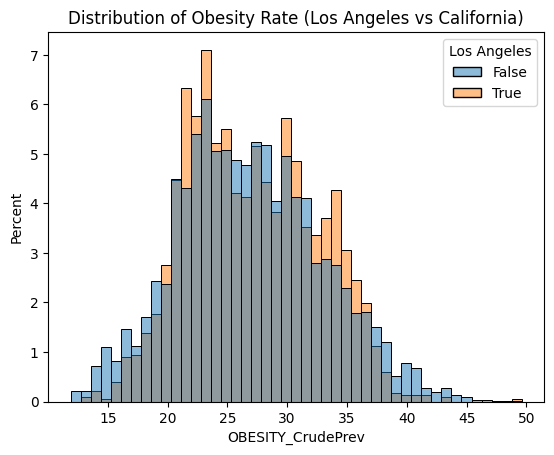

In [20]:
sns.histplot(data=filter_data(comp_data, 'OBESITY_CrudePrev'), x='OBESITY_CrudePrev', hue='Los Angeles', common_norm=False, stat='percent')
plt.title("Distribution of Obesity Rate (Los Angeles vs California)")
plt.show()

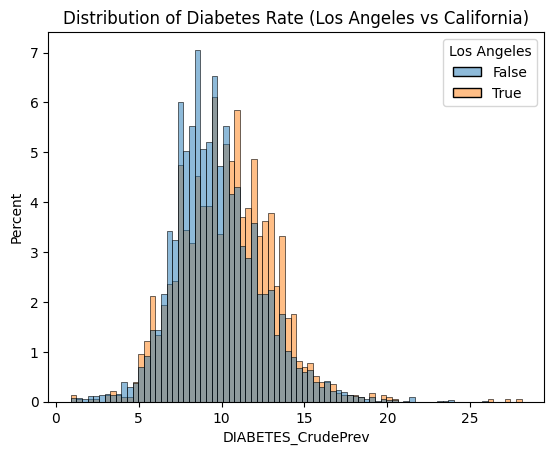

In [21]:
sns.histplot(data=filter_data(comp_data, 'DIABETES_CrudePrev'), x='DIABETES_CrudePrev', hue='Los Angeles', common_norm=False, stat='percent')
plt.title("Distribution of Diabetes Rate (Los Angeles vs California)")
plt.show()